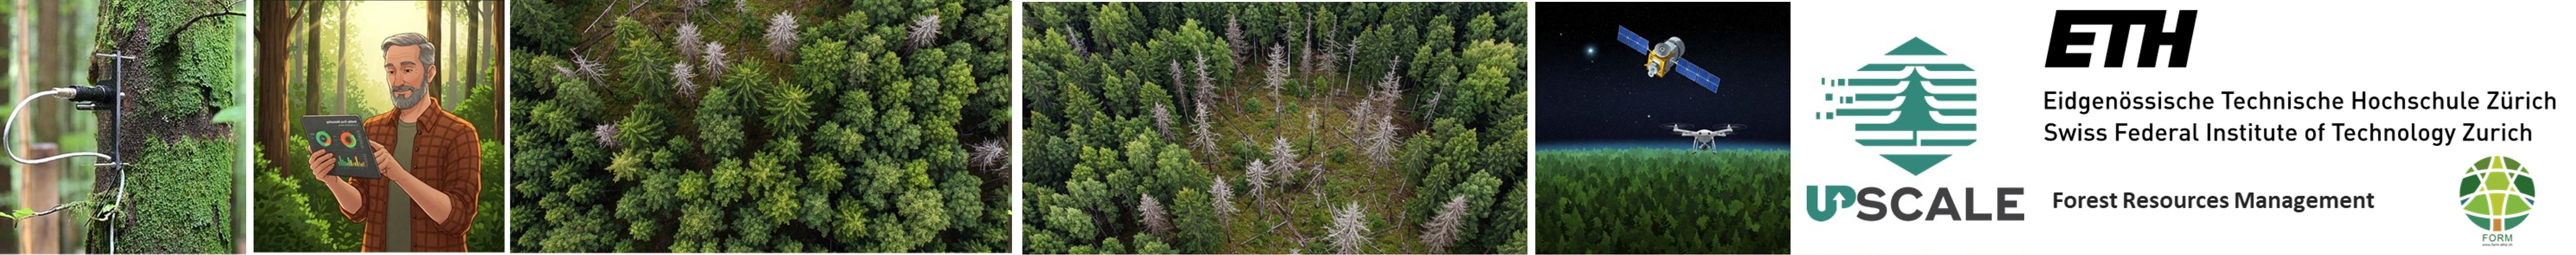

<div class="markdown-google-sans">
  <h1>Welcome to Individual Tree Mortality Identification!</h1>
</div>

<p>Here you can apply a trained deep learning model to identify dead trees on RGB aerial imagery.</p>

### Learning Objectives

By the end of this exercise, you should be able to:

1. **Load and visualize aerial imagery**  
   Read RGB GeoTIFF images, inspect their array shapes, and plot them with `matplotlib` to understand the input data before running a model.

2. **Run object detection inference on one or multiple images**  
   Apply a pretrained YOLO model to Sihlwald aerial images, compare direct resizing with SAHI sliced inference, and process a time series of images from multiple years.

3. **Apply and evaluate post-processing for detection results**  
   Explore how inference parameters such as `conf`, `iou`, and `imgsz` affect predictions, implement Non-Maximum Suppression (NMS), and other task-specific post-processing strategies.


## Dead Trees Detection in Wildnispark Zürich Sihlwald

Forests are essential ecosystems that provide important ecological, climatic, and social functions. Monitoring forest health is therefore a key task in environmental remote sensing. One important indicator of forest condition is the presence of dead trees.

In this part, we focus on one-stage object detection approaches: [YOLO (You Look Only Once)](https://arxiv.org/pdf/2509.25164).

For this exercise, **pretrained models are already provided**. Your task is therefore not to train a model from scratch, but to apply YOLO to aerial imagery collected in [Sihlwald](https://www.wildnispark.ch/de/der-park/naturerlebnispark-sihlwald).

![](/content/drive/MyDrive/Dead_Tree_Detection_Summer_School/img/sihlwald.png)

In [ ]:
from pathlib import Path
import os

# Choose where you are running this notebook: "colab" or "local".
RUN_ENV = "colab"  # Change to "local" if you run the notebook on your own computer.

if RUN_ENV == "colab":
    from google.colab import drive
    drive.mount("/content/drive")

    # Change this path if your project folder has a different name in Google Drive.
    PROJECT_DIR = Path("/content/drive/MyDrive/20260619_TreeDetection")

elif RUN_ENV == "local":
    # If the notebook is opened from the project folder, Path.cwd() should already be correct.
    # Otherwise, replace Path.cwd() with the full path to your local project folder.
    PROJECT_DIR = Path.cwd()

else:
    raise ValueError("RUN_ENV must be either 'colab' or 'local'.")

os.chdir(PROJECT_DIR)

print("Running environment:", RUN_ENV)
print("Current working directory:", Path.cwd())


In [ ]:
from IPython.display import Image, display

img_path = PROJECT_DIR / "img" / "sihlwald.png"
display(Image(filename=str(img_path)))


## 1. Import Required Python Packages

In this step, we import the Python packages required for the exercise.

In [ ]:
# Run this cell if you are using Google Colab or if any required package is missing locally.
# In a local Jupyter environment, this installs packages into the active Python kernel.
%pip install -q ultralytics sahi rasterio geopandas shapely pyogrio


In [ ]:
import ultralytics
import numpy as np
from matplotlib import pyplot as plt
import rasterio
import sahi
from pathlib import Path
import torch
import matplotlib.patches as patches

print("Import Successfully")

We first select the device for running the notebook. It is completely fine if your computer does not have a GPU, as the CPU is sufficient for running this notebook.

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    device_name = torch.cuda.get_device_name(0)
    yolo_device = 0
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    device_name = "Apple Silicon GPU (MPS)"
    yolo_device = "mps"
else:
    device = torch.device("cpu")
    device_name = "CPU"
    yolo_device = "cpu"

print("Selected device:", device)
print("Device name:", device_name)

## 2. Load the Pretrained Model Weights

In this exercise, a dead trees detection YOLO26 model has already been trained for you. We load the pretrained weights so that they can be used for inference on the Sihlwald aerial images.

In [ ]:
from ultralytics import YOLO

weights_path = Path("weights/best.pt")
model = YOLO(weights_path)

## 3. Prepare Aerial Images for Inference

Before running the model, we define a few helper functions and load the aerial images into RGB arrays. These steps make sure that the GeoTIFF data can be passed to YOLO and visualized consistently.


In [ ]:
def draw_yolo_result(ax, img, result, title=""):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

    boxes = result.boxes.xyxy.cpu().numpy()
    scores = result.boxes.conf.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy()

    for box, score, cls_id in zip(boxes, scores, classes):
        xmin, ymin, xmax, ymax = box

        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax.add_patch(rect)

        ax.text(
            xmin,
            max(0, ymin - 3),
            f"dead {score:.2f}",
            color="white",
            fontsize=8,
            bbox=dict(facecolor="red", alpha=0.7, pad=1),
        )

def loadGeoTIFF2RGB(image_path):
    with rasterio.open(image_path) as src:
        img = src.read([1, 2, 3])  # (3, H, W)

    img = np.transpose(img, (1, 2, 0)).astype(np.uint8)
    img = np.ascontiguousarray(img) # Ensure the array is stored in contiguous memory (required by YOLO / OpenCV for visualization)
    return img

### 3.1 Load the aerial images

We first load the selected GeoTIFF files and convert the first three bands into RGB arrays. The printed array shapes help us confirm that the images are much larger than the 512 × 512 tiles used during training.


In [ ]:
test_images = ['data/Sihlwald_Research_Area/research_area_1_2020.tif',
               'data/Sihlwald_Research_Area/research_area_3_2022.tif']

loaded_images = []

for path in test_images:
    img = loadGeoTIFF2RGB(path)
    loaded_images.append(img)
    print(f"Loaded {path} with shape {img.shape}")

### 3.2 Visualize the input images

Before running object detection, it is useful to visualize the input aerial images. This helps us check that the files were loaded correctly, understand the image size, and get a first impression of where dead or stressed trees may appear.

The model was trained on smaller image tiles, while these aerial images are much larger. This size difference is important for the next section, where we compare two inference strategies: resizing the full image and applying sliced inference.


In [ ]:
fig, axes = plt.subplots(1, len(loaded_images), figsize=(16, 8))

if len(loaded_images) == 1:
    axes = [axes]

for ax, img, image_path in zip(axes, loaded_images, test_images):
    ax.imshow(img)
    ax.set_title(f"{Path(image_path).name}\nshape: {img.shape}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## 4. Compare Inference Strategies on Large Aerial Images

During training, the detector learned from small image tiles of **512 × 512 pixels**. However, the aerial images loaded above are much larger than a single training tile.

In this section, we compare two inference strategies:

1. **Resize the full aerial image to the model input size**  
   This is simple and fast, but it compresses the whole scene into one small image.

2. **Apply sliced inference**  
   The large image is split into smaller overlapping windows, and the model runs on each window separately. This better preserves small tree crowns.

Which strategy is more suitable for detecting dead trees in high-resolution aerial imagery?


### 4.1 Option 1: Resize the full image to the model input size (512 × 512)

A straightforward approach is to resize the entire aerial image to **512 × 512 pixels** before feeding it into the model. This matches the input size used by the detector, but it also compresses the whole scene into a much smaller image. As a result, small dead tree crowns may become difficult to detect.


In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

# Run inference on the two loaded images
results = []
for img in loaded_images:
    result = model.predict(
        source=img,
        device=yolo_device,
        imgsz=512,   # resize the full image to the model input size
        conf=0.2, # Confidence threshold: discard predictions with confidence scores below 0.20
        iou=0.45, # IoU threshold for NMS: suppress overlapping boxes that likely refer to the same object
        save=False,
        verbose=False
    )
    results.append(result[0])

#### Visualize Option 1 results

The detections below are produced after resizing the full image to 512 × 512. Use this result as a baseline before comparing it with sliced inference.


In [ ]:
# Visualize both predictions side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, img, result, image_path in zip(axes, loaded_images, results, test_images):
    draw_yolo_result(ax, img, result, title=Path(image_path).name)

plt.tight_layout()
plt.show()

### 4.2 Option 2: Apply sliced inference with SAHI

Another approach is to split the large image into smaller overlapping tiles and run inference on each tile separately. This can be done using **SAHI** (*Slicing Aided Hyper Inference*). Sliced inference is usually better suited for small objects because each tile is closer to the image size used during training.


In [ ]:
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

# Build a SAHI detection model from the same YOLO checkpoint
# Replace model_path with your actual checkpoint path if needed
detection_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=model.ckpt_path,
    confidence_threshold=0.25,
    device=str(device),
)

def sahi_result_to_lists(result):
    boxes, scores, labels = [], [], []
    for obj_pred in result.object_prediction_list:
        bbox = obj_pred.bbox
        score = obj_pred.score.value
        label = obj_pred.category.name

        boxes.append([bbox.minx, bbox.miny, bbox.maxx, bbox.maxy])
        scores.append(score)
        labels.append(label)
    return boxes, scores, labels

# Run SAHI inference on the two loaded images
sahi_results = []
for img in loaded_images:
    result = get_sliced_prediction(
        image=img,
        detection_model=detection_model,
        slice_height=512,
        slice_width=512,
        overlap_height_ratio=0.25,
        overlap_width_ratio=0.25,
        postprocess_type="NMS", # Try different postprocess type, such as "GREEDYNMM", "NMM", see https://github.com/obss/sahi/blob/main/sahi/predict.py for more details
        postprocess_match_metric="IOU",
        postprocess_match_threshold=0.5,
    )
    sahi_results.append(result)

#### Visualize Option 2 results

The detections below are produced with SAHI sliced inference. Compare them with Option 1 and consider whether small dead tree crowns are easier to detect when the image is processed in overlapping tiles.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

for ax, img, result, image_path in zip(axes, loaded_images, sahi_results, test_images):
    ax.imshow(img)
    ax.set_title(Path(image_path).name)
    ax.axis("off")

    boxes, scores, labels = sahi_result_to_lists(result)

    for box, score, label in zip(boxes, scores, labels):
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle((xmin, ymin),  xmax - xmin,
            ymax - ymin, linewidth=2, edgecolor="red",
            facecolor="none" )
        ax.add_patch(rect)

        ax.text( xmin, max(0, ymin - 3),
            f"{label} {score:.2f}",
            color="white", fontsize=8, # If you think the texts are too messy, set 'fontsize' to 0, and 'pad' below to 0 as well
            bbox=dict(facecolor="red", alpha=0.7, pad=1) )

plt.tight_layout()
plt.show()

## 5. Post-processing observations

SAHI already applies its own post-processing during sliced inference, for example merging or suppressing overlapping predictions with NMS-like methods. However, the results above may still contain some imperfect bounding boxes. In particular, two types of errors are useful to inspect here:

1. **Elongated bounding boxes**  
   Some detections may be very narrow or very long. These boxes are unlikely to represent a single tree crown, because individual tree crowns usually appear as more compact objects in the aerial image.

2. **Contained bounding boxes**  
   Sometimes one bounding box is almost completely inside another bounding box. 

In the following exercises, we will design our own post-processing rules for these two problems: one filter for removing elongated boxes, and another filter for handling boxes that are contained inside other boxes.


#### Examples of post-processing issues

The two schematic examples below illustrate the types of bounding boxes we want to handle with custom post-processing filters.

<table>
  <tr>
    <td style="text-align:center">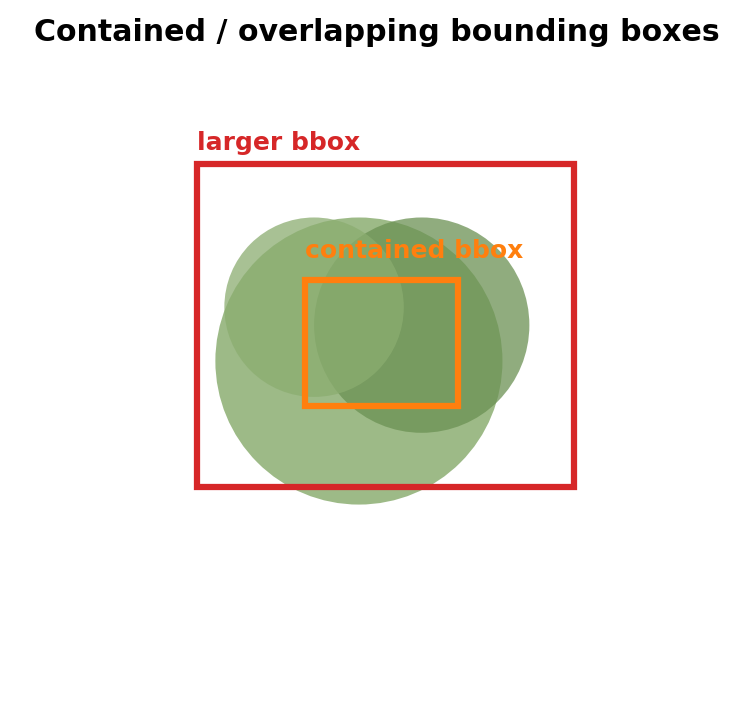</td>
    <td style="text-align:center">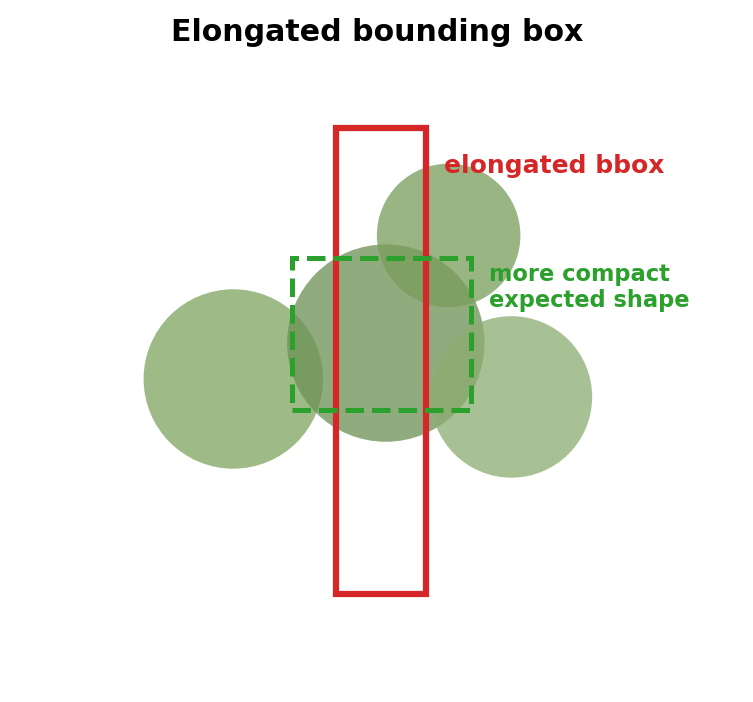</td>
  </tr>
  <tr>
    <td style="text-align:center"><b>Contained / overlapping boxes</b></td>
    <td style="text-align:center"><b>Elongated box</b></td>
  </tr>
</table>


### 5.1 Define custom post-processing filters

We now define two simple filters that target the two problems described above. The first filter removes elongated boxes based on a maximum length-to-width ratio. The second filter removes boxes that are almost completely contained within another box, keeping the higher-confidence detection.


In [ ]:
def box_area(box):
    xmin, ymin, xmax, ymax = box
    return max(0, xmax - xmin) * max(0, ymax - ymin)


def box_aspect_ratio(box):
    xmin, ymin, xmax, ymax = box
    width = max(0, xmax - xmin)
    height = max(0, ymax - ymin)

    if width == 0 or height == 0:
        return np.inf

    return max(width / height, height / width)


def filter_elongated_boxes(boxes, scores, labels, max_aspect_ratio=3.0):
    """Remove boxes that are too elongated to represent a single tree crown."""
    kept_boxes, kept_scores, kept_labels = [], [], []

    for box, score, label in zip(boxes, scores, labels):
        if box_aspect_ratio(box) <= max_aspect_ratio:
            kept_boxes.append(box)
            kept_scores.append(score)
            kept_labels.append(label)

    return kept_boxes, kept_scores, kept_labels


def containment_ratio(inner_box, outer_box):
    """Compute how much of inner_box is covered by outer_box."""
    ixmin, iymin, ixmax, iymax = inner_box
    oxmin, oymin, oxmax, oymax = outer_box

    inter_xmin = max(ixmin, oxmin)
    inter_ymin = max(iymin, oymin)
    inter_xmax = min(ixmax, oxmax)
    inter_ymax = min(iymax, oymax)

    inter_area = max(0, inter_xmax - inter_xmin) * max(0, inter_ymax - inter_ymin)
    inner_area = box_area(inner_box)

    if inner_area == 0:
        return 0.0

    return inter_area / inner_area


def filter_contained_boxes(boxes, scores, labels, containment_threshold=0.9):
    """Remove lower-confidence boxes when one box is contained in another."""
    order = np.argsort(scores)[::-1]

    kept_boxes, kept_scores, kept_labels = [], [], []

    for idx in order:
        box = boxes[idx]
        score = scores[idx]
        label = labels[idx]

        should_keep = True
        for kept_box in kept_boxes:
            box_inside_kept = containment_ratio(box, kept_box) >= containment_threshold
            kept_inside_box = containment_ratio(kept_box, box) >= containment_threshold

            if box_inside_kept or kept_inside_box:
                should_keep = False
                break

        if should_keep:
            kept_boxes.append(box)
            kept_scores.append(score)
            kept_labels.append(label)

    return kept_boxes, kept_scores, kept_labels


def apply_custom_postprocessing(
    boxes,
    scores,
    labels,
    max_aspect_ratio=1.5,
    containment_threshold=0.9,
):
    boxes, scores, labels = filter_elongated_boxes(
        boxes, scores, labels, max_aspect_ratio=max_aspect_ratio
    )

    boxes, scores, labels = filter_contained_boxes(
        boxes, scores, labels, containment_threshold=containment_threshold
    )

    return boxes, scores, labels


### 5.2 Apply the custom filters

The thresholds below are simple starting points. A smaller `max_aspect_ratio` removes more elongated boxes, while a smaller `containment_threshold` removes more boxes that are mostly covered by another detection.


In [ ]:
max_aspect_ratio = 1.5
containment_threshold = 0.8

postprocessed_results = []

for result, image_path in zip(sahi_results, test_images):
    boxes, scores, labels = sahi_result_to_lists(result)

    filtered_boxes, filtered_scores, filtered_labels = apply_custom_postprocessing(
        boxes,
        scores,
        labels,
        max_aspect_ratio=max_aspect_ratio,
        containment_threshold=containment_threshold,
    )

    postprocessed_results.append({
        "boxes": filtered_boxes,
        "scores": filtered_scores,
        "labels": filtered_labels,
    })

    print(
        f"{Path(image_path).name}: {len(boxes)} boxes before custom filters -> "
        f"{len(filtered_boxes)} boxes after custom filters"
    )


### 5.3 Visualize the custom post-processing result

Compare the SAHI output with the result after the two custom filters. This makes it easier to inspect whether elongated boxes or contained boxes were removed as expected.


In [ ]:
fig, axes = plt.subplots(len(loaded_images), 2, figsize=(14, 6 * len(loaded_images)))

if len(loaded_images) == 1:
    axes = np.array([axes])

for row, (img, raw_result, filtered_result, image_path) in enumerate(
    zip(loaded_images, sahi_results, postprocessed_results, test_images)
):
    raw_boxes, raw_scores, raw_labels = sahi_result_to_lists(raw_result)
    plot_data = [
        ({"boxes": raw_boxes, "scores": raw_scores, "labels": raw_labels}, "Before custom filters"),
        (filtered_result, "After custom filters"),
    ]

    for col, (prediction, title) in enumerate(plot_data):
        ax = axes[row, col]
        ax.imshow(img)
        ax.set_title(f"{Path(image_path).name}: {title} ({len(prediction['boxes'])})")
        ax.axis("off")

        for box, score, label in zip(
            prediction["boxes"], prediction["scores"], prediction["labels"]
        ):
            xmin, ymin, xmax, ymax = box
            rect = patches.Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                linewidth=2,
                edgecolor="red",
                facecolor="none",
            )
            ax.add_patch(rect)

plt.tight_layout()
plt.show()


#### Open Question

*Why do the two post-processing problems shown above occur? (Hints: Think about the image size, the slicing strategy, the model confidence scores, and how NMS decides whether two boxes should be merged or suppressed.)*


## Exercise 1. Explore Inference and Post-processing Hyperparameters

In this exercise, you will experiment with the parameters used throughout the detection workflow, from model inference to sliced prediction and post-processing. The goal is to observe how different parameter settings change the final detection result.

Try adjusting parameters in the cells below, rerun the prediction, and compare the visual results. Pay attention to missed detections, false detections, duplicated boxes, elongated boxes, and boxes that contain one another.

Examples of parameters you can explore include:

- `confidence_threshold` / `conf` — controls which low-confidence predictions are kept
- `postprocess_match_threshold` / `iou` — controls how strongly overlapping boxes are merged or suppressed
- `slice_height` and `slice_width` — control the size of the image windows used by SAHI
- `overlap_height_ratio` and `overlap_width_ratio` — control how much neighboring slices overlap
- `max_aspect_ratio` — controls how strict the elongated-box filter is
- `containment_threshold` — controls how strict the contained-box filter is

Your task is to find a parameter combination that you think gives the best balance between detecting real dead trees and removing problematic boxes. There is not a single perfect answer, so justify your choice based on the visual results.


## Exercise 2. Time Series Analysis of Sihlwald Dead Trees

In this exercise, we will analyze aerial images from different years and observe how dead tree patterns change over time. The test images are still aerial images from the Sihlwald forest, so the parameter-tuning experience from Exercise 1 is directly relevant here.

You can reuse the inference and post-processing settings that worked well in Exercise 1, and then apply them consistently across all years to make the time series comparison more meaningful.

### Step 1: Load and visualize the time series images

As a first step, load the images from `data/test_data_500m` and visualize them side by side. This helps you check whether the images are correctly loaded and visually compare the same forest area across years.


In [ ]:
time_series_dir = Path("data/test_data_500m")
time_series_images = sorted(time_series_dir.glob("*.tif"))

loaded_time_series_images = []

for image_path in time_series_images:
    # TODO: load each GeoTIFF as an RGB image.
    img = ...
    loaded_time_series_images.append(img)
    print(f"Loaded {image_path.name} with shape {img.shape}")

# TODO: visualize all time series images side by side.
fig, axes = ...

if len(loaded_time_series_images) == 1:
    axes = [axes]

for ax, img, image_path in zip(axes, loaded_time_series_images, time_series_images):
    # TODO: display the image and add a useful title.
    ...

plt.tight_layout()
plt.show()


### Step 2: Run the Dead Tree Detection Model on the Time Series Images

Now apply the pretrained YOLO model to all four images. Since dead trees can be small compared with the full image size, we use the sliced inference workflow introduced above.

For this time series, we use a lower confidence threshold (`0.10`) to reduce missed detections in the 2024 image. We intentionally keep overlapping candidate boxes from SAHI so that you can implement your own NMS in the next step.


In [ ]:
# Set this to True if you want to display confidence scores on the boxes.
# Keep it False for a cleaner visualization with red boxes only.
show_confidence = False

# TODO: choose the SAHI/post-processing settings you want to use.
sahi_confidence_threshold = ...
sahi_slice_size = ...
sahi_overlap_ratio = ...
sahi_merge_threshold = ...

# TODO: build a SAHI detection model from the YOLO checkpoint.
time_series_detection_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=...,
    confidence_threshold=...,
    device=...,
)

time_series_sahi_results = []

for img, image_path in zip(loaded_time_series_images, time_series_images):
    # TODO: run sliced prediction on each image.
    result = ...

    time_series_sahi_results.append(result)
    print(f"{image_path.name}: {len(result.object_prediction_list)} detections")

# TODO: visualize the raw SAHI detections for each year.
fig, axes = ...

if len(loaded_time_series_images) == 1:
    axes = [axes]

for ax, img, result, image_path in zip(
    axes, loaded_time_series_images, time_series_sahi_results, time_series_images
):
    # TODO: show the image, convert the SAHI result to boxes/scores/labels,
    # and draw the candidate boxes.
    boxes, scores, labels = ...

    for box, score, label in zip(boxes, scores, labels):
        xmin, ymin, xmax, ymax = box
        rect = ...
        ax.add_patch(rect)

        if show_confidence:
            # TODO: optionally draw the confidence score next to each box.
            ...

plt.tight_layout()
plt.show()


### Step 3: Implement your own Non-Maximum Suppression (NMS)

The sliced inference result above intentionally keeps many overlapping candidate boxes. In this step, you will implement Non-Maximum Suppression (NMS) to remove redundant boxes.

Your NMS function should keep the box with the highest confidence score and suppress lower-confidence boxes that strongly overlap with it.


#### Step 3.1: Collect the candidate boxes from SAHI

First, convert the SAHI prediction objects into simple Python lists of boxes, scores, and labels. These are the inputs for your NMS function.


In [ ]:
time_series_candidates = {}

for image_path, result in zip(time_series_images, time_series_sahi_results):
    # TODO: convert the SAHI result into lists of boxes, scores, and labels.
    boxes, scores, labels = ...

    time_series_candidates[image_path.stem] = {
        "image_path": image_path,
        "boxes": boxes,
        "scores": scores,
        "labels": labels,
    }

    print(f"{image_path.stem}: {len(boxes)} candidate boxes before NMS")


#### Step 3.2: Define the function for computing IoU

Before implementing NMS, we first need to compute the **Intersection over Union (IoU)** between two bounding boxes. IoU measures how much two boxes overlap and is defined as:

$$
\text{IoU} = \frac{\text{Area of Overlap}}{\text{Area of Union}}
$$

Each bounding box is represented as `[xmin, ymin, xmax, ymax]`.


In [ ]:
def compute_iou(box1, box2):
    """
    Compute Intersection over Union (IoU) between two bounding boxes.

    Each box is represented as [xmin, ymin, xmax, ymax].
    """
    # TODO 1): Find the coordinates of the intersection rectangle.
    x1 = ...
    y1 = ...
    x2 = ...
    y2 = ...

    # TODO 2): Compute the width and height of the overlapping area.
    # If the boxes do not overlap horizontally or vertically, the width and height should be 0.
    inter_w = ...
    inter_h = ...

    # TODO 3): Compute the intersection area.
    inter_area = ...

    # TODO 4): Compute the area of each input box.
    area1 = ...
    area2 = ...

    # TODO 5): Compute the union area.
    union_area = ...

    # TODO 6): Avoid division by zero if the union area is 0.
    if union_area == 0:
        return 0.0

    # TODO 7): Return the IoU value.
    return ...


#### Step 3.3: Define your NMS function

The function should keep the bounding box with the highest confidence score, compare it with the remaining boxes, and suppress all boxes whose IoU is above the threshold. This process should then be repeated until all boxes have been processed.


In [ ]:
def nms(boxes, scores, labels, iou_threshold=0.5):
    """
    Apply Non-Maximum Suppression (NMS) to a set of predicted bounding boxes.

    Parameters
    ----------
    boxes : list of list
        Bounding boxes in the format [xmin, ymin, xmax, ymax]
    scores : list of float
        Confidence scores for each box
    labels : list
        Class labels for each box
    iou_threshold : float
        IoU threshold above which boxes are suppressed

    Returns
    -------
    kept_boxes, kept_scores, kept_labels
    """
    # TODO 1): Convert the input lists to numpy arrays.
    boxes = ...
    scores = ...
    labels = ...

    if len(boxes) == 0:
        return [], [], []

    # TODO 2): Sort box indices by confidence score in descending order.
    order = ...

    kept_boxes = []
    kept_scores = []
    kept_labels = []

    # TODO 3): Repeatedly select the highest-confidence remaining box.
    while len(order) > 0:
        current_idx = ...

        # TODO 4): Keep the selected box, score, and label.
        kept_boxes.append(...)
        kept_scores.append(...)
        kept_labels.append(...)

        # TODO 5): Compare the selected box with the remaining boxes.
        remaining_indices = ...
        keep_remaining = []

        for idx in remaining_indices:
            # TODO 6): Compute IoU and decide whether this remaining box should be kept.
            iou = ...

            if ...:
                keep_remaining.append(idx)

        # TODO 7): Update the list of boxes that still need to be processed.
        order = ...

    return kept_boxes, kept_scores, kept_labels


#### Step 3.4: Apply your NMS function to the time series detections

After completing the two functions above, run your NMS on the candidate boxes from each year. Try different IoU thresholds and observe how the number of boxes changes.


In [ ]:
student_nms_iou_threshold = ...
student_nms_results = {}

for image_name, prediction in time_series_candidates.items():
    # TODO: apply your NMS function to each year's candidate boxes.
    boxes_student_nms, scores_student_nms, labels_student_nms = ...

    student_nms_results[image_name] = {
        "boxes": boxes_student_nms,
        "scores": scores_student_nms,
        "labels": labels_student_nms,
    }

    print(
        f"{image_name}: {len(prediction['boxes'])} boxes before NMS -> "
        f"{len(boxes_student_nms)} boxes after your NMS"
    )


In [ ]:
for image_name, result in student_nms_results.items():
    boxes_student_nms = result["boxes"]
    scores_student_nms = result["scores"]
    labels_student_nms = result["labels"]

    assert len(boxes_student_nms) == len(scores_student_nms) == len(labels_student_nms), \
        f"{image_name}: Your NMS output is inconsistent. Boxes, scores, and labels must have the same length."

    print(f"{image_name}: Assertion passed")


### Step 4: Visualize your NMS result

Compare the original SAHI candidate boxes with the boxes kept by your NMS implementation. If your NMS works correctly, many duplicated boxes around the same tree should disappear.

When the bounding boxes are too dense, the third column shows only the center points of the boxes kept after NMS. This provides a cleaner view of the spatial distribution of detected dead trees.


In [ ]:
fig, axes = plt.subplots(len(time_series_images), 3, figsize=(21, 5 * len(time_series_images)))

if len(time_series_images) == 1:
    axes = np.array([axes])

for row, (img, image_path) in enumerate(zip(loaded_time_series_images, time_series_images)):
    image_name = image_path.stem
    raw = time_series_candidates[image_name]
    nms_result = student_nms_results[image_name]

    plot_data = [
        (raw, f"{image_name}: before NMS ({len(raw['boxes'])})"),
        (nms_result, f"{image_name}: after your NMS ({len(nms_result['boxes'])})"),
    ]

    for col, (prediction, title) in enumerate(plot_data):
        ax = axes[row, col]

        # TODO: visualize the image and draw the boxes for this panel.
        ...

        for box, score, label in zip(prediction["boxes"], prediction["scores"], prediction["labels"]):
            xmin, ymin, xmax, ymax = box
            rect = ...
            ax.add_patch(rect)

            if show_confidence:
                # TODO: optionally draw confidence scores.
                ...

    ax = axes[row, 2]

    # TODO: visualize the image and draw only center points for the NMS result.
    centers_x = []
    centers_y = []

    for box in nms_result["boxes"]:
        xmin, ymin, xmax, ymax = box
        center_x = ...
        center_y = ...
        centers_x.append(center_x)
        centers_y.append(center_y)

    # TODO: draw the center points with ax.scatter(...).
    ...

plt.tight_layout()
plt.show()


### Step 5: Explore the effect of different IoU thresholds

Experiment with different values of `student_nms_iou_threshold`, such as `0.10`, `0.30`, `0.50`, and `0.70`. What exactly does the IoU threshold control? How does it affect duplicated boxes and nearby true detections?


### Step 6: Apply the custom post-processing filters after NMS

After your NMS step, we can further apply the two custom filters designed earlier: the elongated-box filter and the contained-box filter. This gives us a final set of detections that removes many duplicated or unrealistic boxes.

The figures below are relatively small because they show multiple years side by side. If you want to inspect the results carefully, export the detections in the final step and open them in GIS software, where you can zoom in and compare them with the aerial imagery.


In [ ]:
time_series_max_aspect_ratio = ...
time_series_containment_threshold = ...

final_postprocessed_results = {}

for image_name, nms_result in student_nms_results.items():
    # TODO: apply the elongated-box and contained-box filters from Section 5.
    filtered_boxes, filtered_scores, filtered_labels = ...

    final_postprocessed_results[image_name] = {
        "boxes": filtered_boxes,
        "scores": filtered_scores,
        "labels": filtered_labels,
    }

    print(
        f"{image_name}: {len(nms_result['boxes'])} boxes after NMS -> "
        f"{len(filtered_boxes)} boxes after custom filters"
    )

# TODO: visualize the NMS result and the final filtered result side by side.
fig, axes = ...

if len(time_series_images) == 1:
    axes = np.array([axes])

for row, (img, image_path) in enumerate(zip(loaded_time_series_images, time_series_images)):
    image_name = image_path.stem
    nms_result = student_nms_results[image_name]
    final_result = final_postprocessed_results[image_name]

    plot_data = [
        (nms_result, f"{image_name}: after NMS ({len(nms_result['boxes'])})"),
        (final_result, f"{image_name}: after custom filters ({len(final_result['boxes'])})"),
    ]

    for col, (prediction, title) in enumerate(plot_data):
        ax = axes[row, col]

        # TODO: show the image, draw the boxes, and optionally show confidence scores.
        ...

plt.tight_layout()
plt.show()


### Step 7: Visualize the change in detected dead trees over time

Finally, summarize the final post-processed detections as a simple time series. Count the number of detected dead trees in each year and plot how this number changes over time.

This plot provides a compact overview of the temporal pattern, but remember that the numbers depend on the confidence threshold, the NMS threshold, the custom post-processing thresholds, and the quality of the model predictions.


In [ ]:
dead_tree_counts = []

for image_path in time_series_images:
    image_name = image_path.stem

    # TODO: extract the year from the image name and count final detections.
    year = ...
    count = ...

    dead_tree_counts.append((year, count))

dead_tree_counts = ...
years = ...
counts = ...

# TODO: plot the number of detected dead trees over time.
fig, ax = ...

ax.plot(...)

for year, count in zip(years, counts):
    # TODO: add count labels to the curve.
    ...

ax.set_title("Detected dead trees over time")
ax.set_xlabel("Year")
ax.set_ylabel("Number of detected dead trees")
ax.set_xticks(years)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Step 8: Export the final detections to GeoPackage files

Export the final post-processed detections to GeoPackage files so that the results can be opened and visualized in GIS software such as QGIS or ArcGIS.

Here, each year is exported as a separate GeoPackage. Each file contains two layers: one layer with bounding box polygons and one layer with center points. The only attribute kept is the confidence score.


In [ ]:
import geopandas as gpd
from shapely.geometry import box, Point

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

for image_path in time_series_images:
    image_name = image_path.stem

    # TODO: extract the year and select the final post-processed result for this image.
    year = ...
    result = ...
    gpkg_path = output_dir / f"dead_tree_detections_{year}.gpkg"

    if gpkg_path.exists():
        gpkg_path.unlink()

    bbox_records = []
    point_records = []

    with rasterio.open(image_path) as src:
        transform = ...
        crs = ...

    for pixel_box, score in zip(result["boxes"], result["scores"]):
        xmin, ymin, xmax, ymax = pixel_box

        # TODO: convert pixel coordinates to map coordinates.
        x_left, y_top = ...
        x_right, y_bottom = ...
        x_center, y_center = ...

        minx, maxx = ...
        miny, maxy = ...

        # TODO: create one polygon record and one point record.
        bbox_records.append(...)
        point_records.append(...)

    # TODO: create GeoDataFrames and export them to separate layers in one GeoPackage.
    bbox_gdf = ...
    point_gdf = ...

    bbox_gdf.to_file(gpkg_path, layer="bboxes", driver="GPKG")
    point_gdf.to_file(gpkg_path, layer="centers", driver="GPKG")

    print(f"{year}: exported {len(bbox_gdf)} detections to {gpkg_path}")


### Step 9: Reflect on your GIS visualization

After opening the exported GeoPackage files in GIS software, inspect the detections together with the aerial imagery. Are you satisfied with the final result?

Consider the following questions:

- Are there still obvious missed dead trees?
- Are there false detections that should have been removed?
- Did your NMS and custom post-processing filters remove too many boxes or too few boxes?
- How does your result compare with the result from the student or teammate sitting next to you?
- Which parameter choices led to the best visual result, and why?
